# AI Worker Burnout and Attrition Dataset

## Initial Dataset Exploration



In [27]:
# Import libraries for data loading and visualization

import pandas as pd
import matplotlib.pyplot as plt

# Load the raw AI worker burnout and attrition dataset

df = pd.read_csv("../data/raw/ai_worker_burnout_attrition_2026.csv")

# Display the first rows of the dataset

df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [28]:
# Display the number of rows and columns

df.shape

(1500, 21)

In [29]:
# Review dataset structure and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   str    
 1   job_role                        1500 non-null   str    
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   str    
 4   country                         1500 non-null   str    
 5   industry                        1500 non-null   str    
 6   company_size                    1500 non-null   str    
 7   remote_work_type                1500 non-null   str    
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   str    
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  1500 non-null

#  Descriptive Statistics

Descriptive statistics help understand the scale, range, and distribution of numerical variables.

This step can also reveal potential outliers or unusual values.

In [30]:
# Generate descriptive statistics for numerical variables

df.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


# Missing Values

Missing values are checked before any cleaning decisions are made.



In [31]:
# Check the number of missing values in each column

df.isna().sum()

employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64

# Column Overview



In [32]:
# Display all column names

df.columns

Index(['employee_id', 'job_role', 'years_experience', 'education_level',
       'country', 'industry', 'company_size', 'remote_work_type', 'team_size',
       'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day',
       'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct',
       'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score',
       'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement',
       'attrition_risk'],
      dtype='str')

# Duplicate Records



In [33]:
# Check the number of duplicated rows

df.duplicated().sum()

np.int64(0)

# Target Variable Review

Two key outcome variables are inspected:

- `burnout_score`
- `attrition_risk`

`burnout_score` is a numerical indicator of burnout intensity, while `attrition_risk` is a categorical target variable for employee retention risk.

In [34]:
# Review the distribution of the burnout score

df["burnout_score"].describe()

count    1500.000000
mean       50.057333
std        11.437771
min        16.000000
25%        42.000000
50%        50.000000
75%        58.000000
max        86.000000
Name: burnout_score, dtype: float64

In [35]:
# Check the distribution of attrition risk categories

df["attrition_risk"].value_counts()

attrition_risk
Low       724
Medium    691
High       85
Name: count, dtype: int64

### Target variable interpretation

The burnout score provides a continuous measure that can be used for regression-style analysis or as an explanatory variable.

The attrition risk variable is especially important for classification modeling, because it indicates whether employees are at higher or lower risk of leaving.

# Numerical and Categorical Variables



In [36]:
# Identify numerical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

numerical_cols

Index(['years_experience', 'team_size', 'salary_usd_k',
       'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
       'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
       'productivity_score', 'burnout_score', 'job_satisfaction_1_5'],
      dtype='str')

In [37]:
# Identify categorical columns

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

categorical_cols

/var/folders/_d/9zcx7q8s1yb7ztxbxc0bg95w0000gn/T/ipykernel_44309/3063533895.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


Index(['employee_id', 'job_role', 'education_level', 'country', 'industry',
       'company_size', 'remote_work_type', 'primary_ai_tool',
       'ai_adoption_stage', 'fear_of_ai_replacement', 'attrition_risk'],
      dtype='str')

# Categorical Variable Inspection



In [38]:
# Display unique values and number of categories for each categorical variable

for col in categorical_cols:
    print(col)
    print("Number of unique values:", df[col].nunique())
    print(df[col].unique())
    print("-" * 30)

employee_id
Number of unique values: 1500
<StringArray>
['EMP0001', 'EMP0002', 'EMP0003', 'EMP0004', 'EMP0005', 'EMP0006', 'EMP0007',
 'EMP0008', 'EMP0009', 'EMP0010',
 ...
 'EMP1491', 'EMP1492', 'EMP1493', 'EMP1494', 'EMP1495', 'EMP1496', 'EMP1497',
 'EMP1498', 'EMP1499', 'EMP1500']
Length: 1500, dtype: str
------------------------------
job_role
Number of unique values: 12
<StringArray>
[     'Data Analyst',   'DevOps Engineer',   'Prompt Engineer',
  'Backend Engineer',     'AI Researcher', 'AI Ethics Officer',
    'Data Scientist',   'Product Manager',       'ML Engineer',
   'Cloud Architect', 'Software Engineer', 'Frontend Engineer']
Length: 12, dtype: str
------------------------------
education_level
Number of unique values: 5
<StringArray>
['PhD', 'Self-taught', 'Master', 'Bachelor', 'Bootcamp']
Length: 5, dtype: str
------------------------------
country
Number of unique values: 10
<StringArray>
[      'India',      'Canada',     'Germany',         'USA',   'Singapore',
 'Net

# Numerical Distributions

Histograms provide a first visual overview of numerical variable distributions.

This helps identify skewed variables, unusual ranges, and potential outliers.

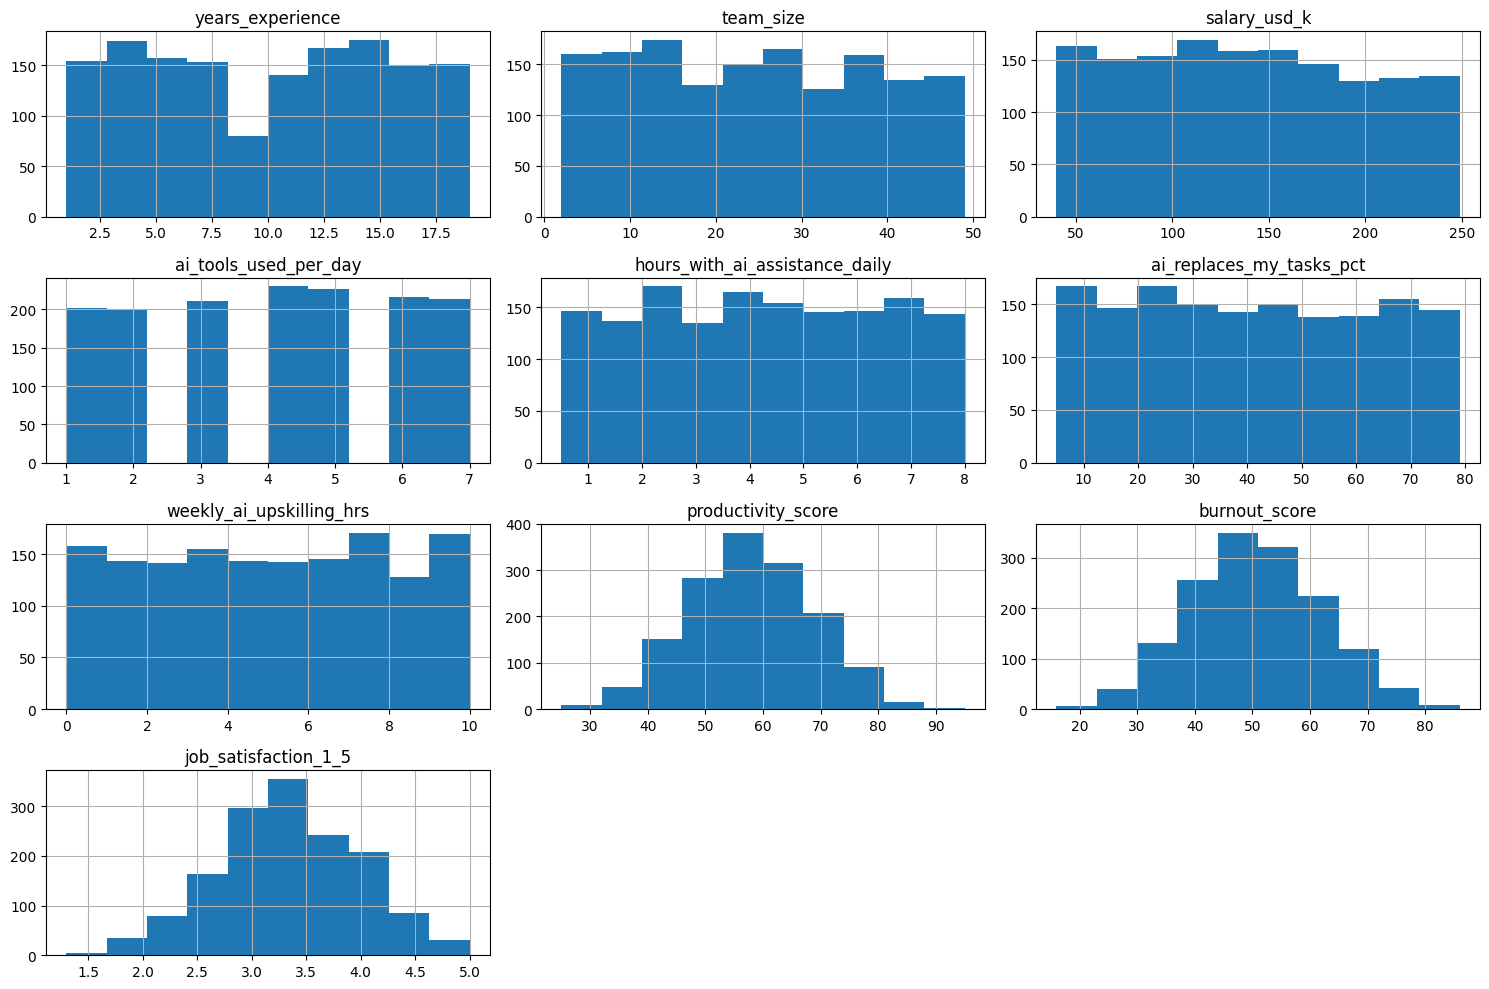

In [39]:
# Plot histograms for all numerical variables

df[numerical_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

# Correlation Analysis

Correlation analysis is used to identify linear relationships between numerical variables.


In [40]:
# Calculate correlations between numerical variables

corr = df[numerical_cols].corr()

corr

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
years_experience,1.000000,-0.000632,0.016165,0.046315,0.000652,-0.004695,0.039724,-0.016252,0.004534,0.010081
team_size,-0.000632,1.000000,-0.018781,-0.023717,0.042336,0.024850,0.025271,-0.024014,0.017171,-0.002859
salary_usd_k,0.016165,-0.018781,1.000000,0.020063,0.016641,0.018664,-0.011728,0.032107,0.013118,-0.016315
ai_tools_used_per_day,0.046315,-0.023717,0.020063,1.000000,0.020176,0.009816,-0.030743,0.308280,-0.003333,0.052379
hours_with_ai_assistance_daily,0.000652,0.042336,0.016641,0.020176,1.000000,0.034775,-0.027980,0.043123,0.385597,-0.254970
ai_replaces_my_tasks_pct,-0.004695,0.024850,0.018664,0.009816,0.034775,1.000000,0.005908,-0.014330,0.613375,-0.399918
weekly_ai_upskilling_hrs,0.039724,0.025271,-0.011728,-0.030743,-0.027980,0.005908,1.000000,-0.015834,-0.014869,-0.026773
productivity_score,-0.016252,-0.024014,0.032107,0.308280,0.043123,-0.014330,-0.015834,1.000000,-0.005322,0.005371
burnout_score,0.004534,0.017171,0.013118,-0.003333,0.385597,0.613375,-0.014869,-0.005322,1.000000,-0.629328
job_satisfaction_1_5,0.010081,-0.002859,-0.016315,0.052379,-0.254970,-0.399918,-0.026773,0.005371,-0.629328,1.000000


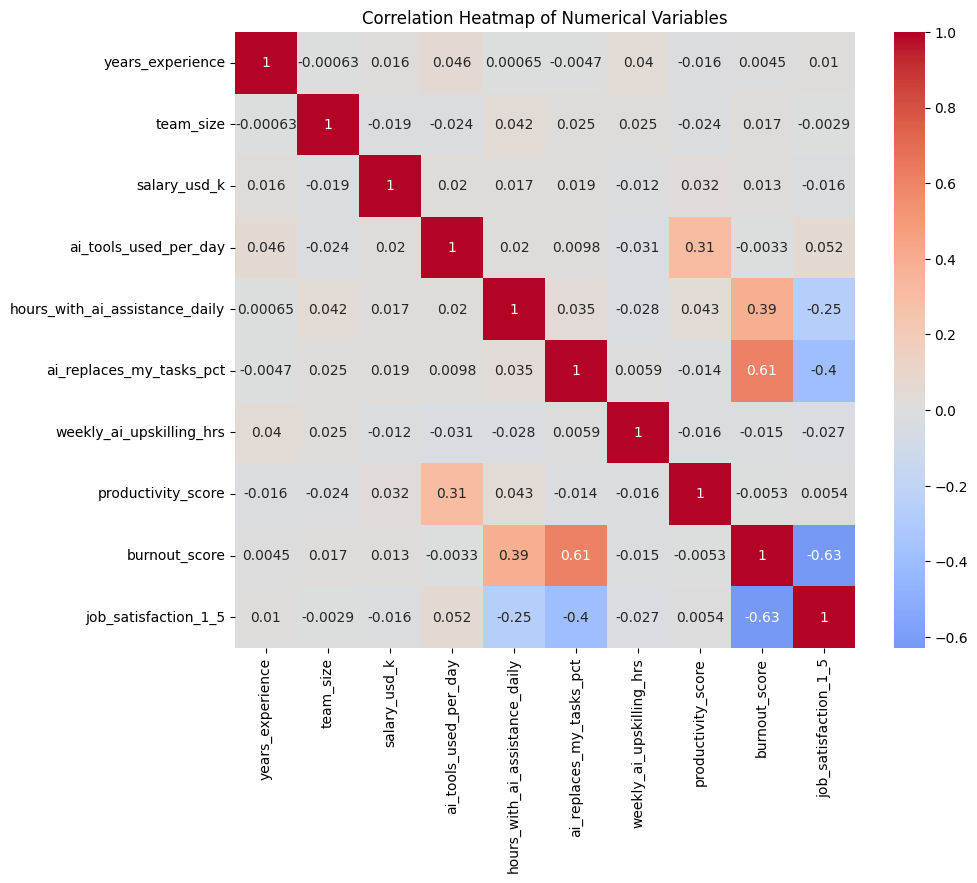

In [41]:
# Import visualization libraries

import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the correlation matrix

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### Correlation interpretation

The correlation heatmap provides an initial overview of which numerical variables may be related to burnout and attrition risk.

Variables that show stronger correlations with `burnout_score` should be examined more closely in the EDA notebook.

However, correlation does not imply causation. The heatmap should be used as a guide for further analysis rather than as a final conclusion.

# Exploration Summary

The initial dataset exploration showed that the dataset contains both numerical and categorical variables relevant to employee burnout and attrition.

Main observations from this notebook:

- The dataset was loaded successfully from the raw data folder.
- Dataset dimensions, data types, and column names were inspected.
- Missing values and duplicate rows were checked.
- The main outcome variables, `burnout_score` and `attrition_risk`, were reviewed.
- Numerical and categorical variables were identified.
- Initial histograms and correlations were generated.

The next step is data cleaning, where variable types, missing values, categorical values, and potential duplicates will be handled before detailed EDA and modeling.